# Section 2 - Exploratory Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# Read raw file
df = pd.read_csv('/Users/moyusii/Desktop/winequality-red-1.csv', header=None)

# Correct dataset
df = df[0].str.split(';', expand=True)
df.columns = df.iloc[0]
df.columns = df.columns.str.replace('"', '').str.strip()
df = df.drop(0)
df = df.reset_index(drop=True)
df = df.apply(pd.to_numeric)

print(df.head())
print(df.shape)
print(df.describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(3).to_string())

0  fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

0  free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

0  alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

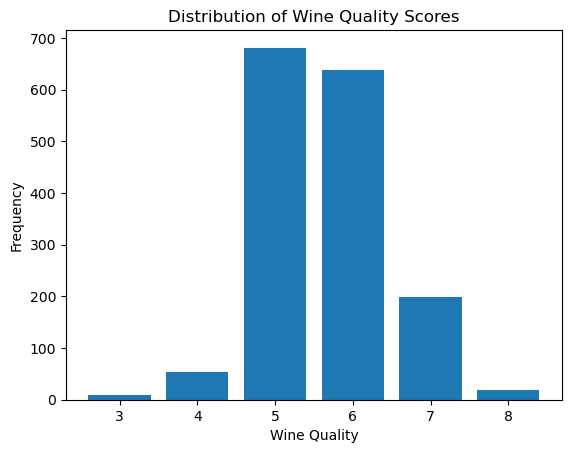

In [ ]:
# Vis 1: Distribution of wine quality scores

quality_counts = df["quality"].value_counts().sort_index()

plt.bar(quality_counts.index, quality_counts.values)
plt.xlabel('Wine Quality')
plt.ylabel('Frequency')
plt.title('Distribution of Wine Quality Scores')
plt.xticks(quality_counts.index)
plt.show()

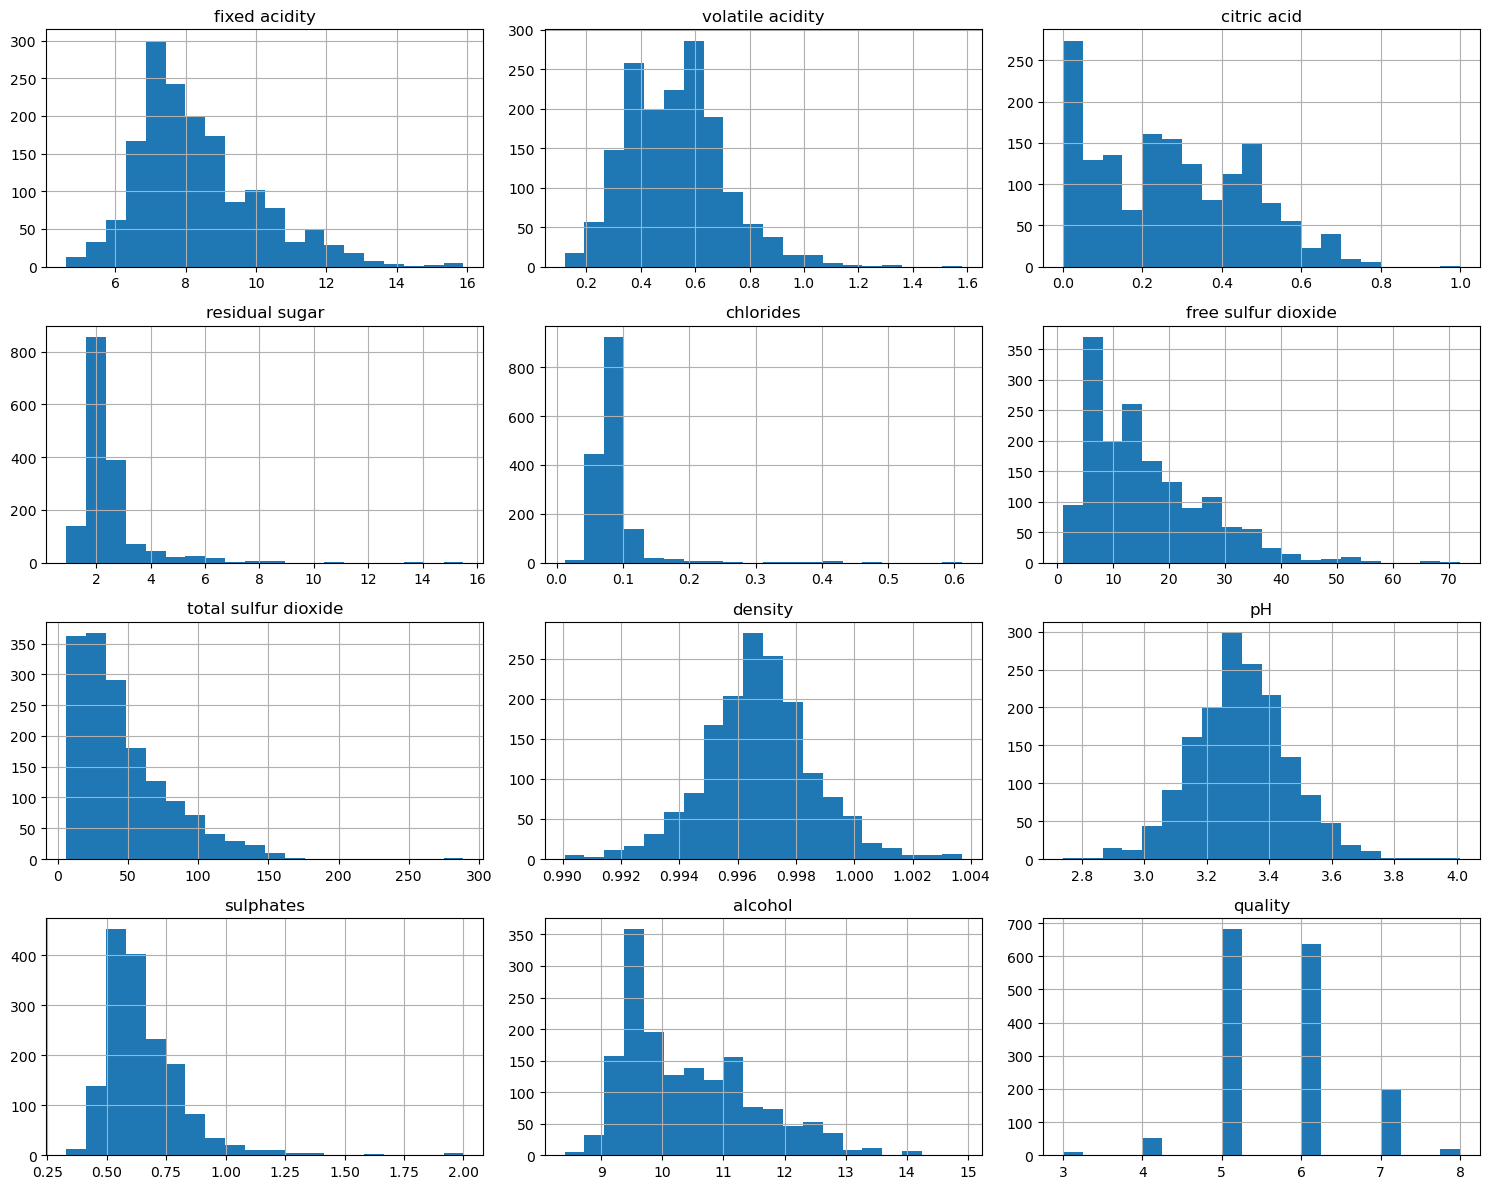

In [ ]:
# Vis 2: Histograms for all features

df.hist(figsize=(15,12), bins=20)
plt.tight_layout()
plt.show()

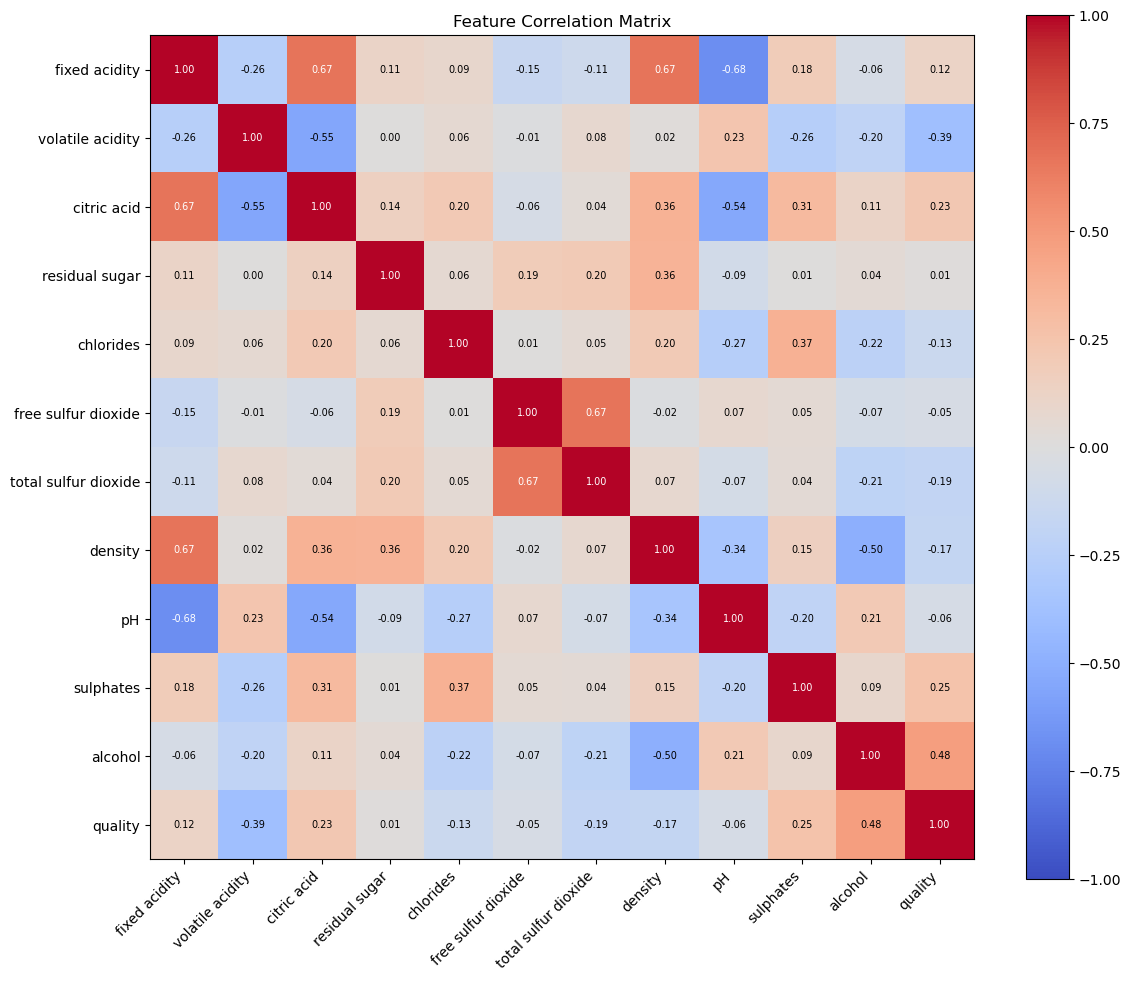

In [20]:
# Vis 3: Correlation matrix
corr_matrix = df.corr()
n = len(corr_matrix)

plt.figure(figsize=(12,10))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(n), corr_matrix.columns, rotation=45, ha='right')
plt.yticks(range(n), corr_matrix.columns)

for i in range(n):
    for j in range(n):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        plt.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7, color=color)

plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

/var/folders/l4/4s0srnq16xx1jj01k4bvdr9w0000gn/T/ipykernel_72704/3273257418.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=quality_levels)
/var/folders/l4/4s0srnq16xx1jj01k4bvdr9w0000gn/T/ipykernel_72704/3273257418.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=quality_levels)
/var/folders/l4/4s0srnq16xx1jj01k4bvdr9w0000gn/T/ipykernel_72704/3273257418.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=quality_levels)
/var/folders/l4/4s0srnq16xx1jj01k4bvdr9w0000gn/T/ipykernel_72704/3273257418.py:10: MatplotlibDeprecationWarni

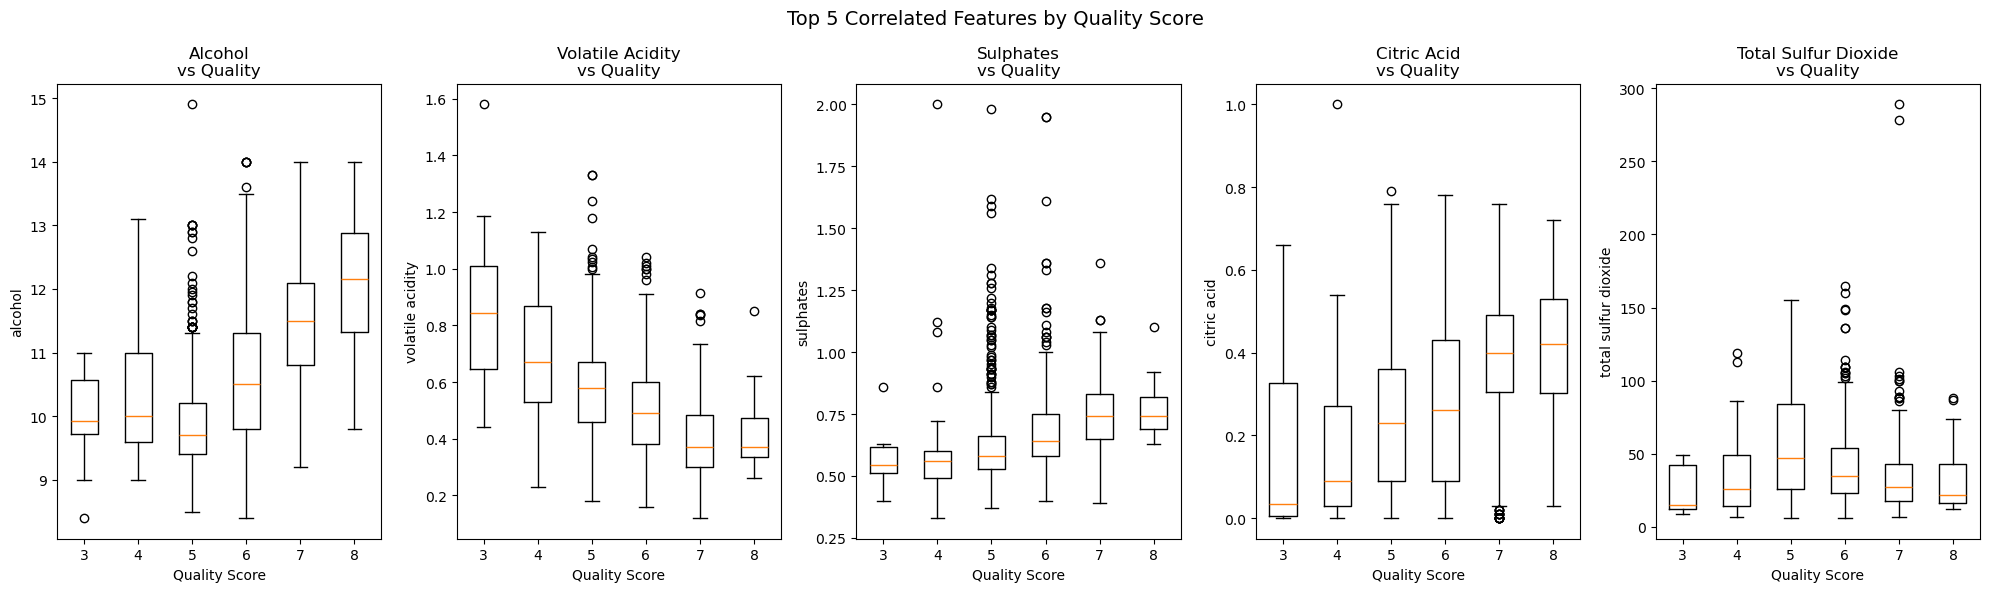

Feature correlations with quality (absolute value):
0
alcohol                 0.476
volatile acidity        0.391
sulphates               0.251
citric acid             0.226
total sulfur dioxide    0.185
density                 0.175
chlorides               0.129
fixed acidity           0.124
pH                      0.058
free sulfur dioxide     0.051
residual sugar          0.014


In [14]:
# Vis 4: Boxplots of top 5 features correlated with quality
quality_corr = corr_matrix['quality'].drop('quality').abs().sort_values(ascending=False)
top_features = quality_corr.head(5).index.tolist()
quality_levels = sorted(df['quality'].unique())

plt.figure(figsize=(20, 6))
for i, feature in enumerate(top_features):
    plt.subplot(1, 5, i + 1)
    groups = [df[df['quality'] == q][feature] for q in quality_levels]
    plt.boxplot(groups, labels=quality_levels)
    plt.xlabel('Quality Score')
    plt.ylabel(feature)
    plt.title(f'{feature.title()}\nvs Quality')

plt.suptitle('Top 5 Correlated Features by Quality Score', fontsize=14)
plt.tight_layout()
plt.show()

print("Feature correlations with quality (absolute value):")
print(quality_corr.round(3).to_string())

In [15]:
# Exploratory findings

# Average feature values grouped by quality
quality_summary = df.groupby('quality').mean()
print(quality_summary)

# Identify strongest correlations with quality
quality_corr = corr_matrix['quality'].sort_values(ascending=False)
print(quality_corr)

0        fixed acidity  volatile acidity  citric acid  residual sugar  \
quality                                                                 
3             8.360000          0.884500     0.171000        2.635000   
4             7.779245          0.693962     0.174151        2.694340   
5             8.167254          0.577041     0.243686        2.528855   
6             8.347179          0.497484     0.273824        2.477194   
7             8.872362          0.403920     0.375176        2.720603   
8             8.566667          0.423333     0.391111        2.577778   

0        chlorides  free sulfur dioxide  total sulfur dioxide   density  \
quality                                                                   
3         0.122500            11.000000             24.900000  0.997464   
4         0.090679            12.264151             36.245283  0.996542   
5         0.092736            16.983847             56.513950  0.997104   
6         0.084956            15.711599 